# Moving Averages Stock Price Prediction

Stock Price Prediction model using moving averages.

In [24]:
#packages

import pandas as pd
import pytz
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score


## Downloading stock price data

In [25]:
import yfinance as yf

In [26]:
ticker= yf.Ticker("AAPL")

In [27]:
name= ticker.info["shortName"]
name

'Apple Inc.'

In [28]:
df= ticker.history(period= "10y")
#set period of data collected

In [29]:
#Show data
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-03-21 00:00:00-04:00,23.991074,24.380621,23.812155,23.986546,142010800,0.0,0.0
2016-03-22 00:00:00-04:00,23.837068,24.299088,23.828008,24.169994,129777600,0.0,0.0
2016-03-23 00:00:00-04:00,24.115643,24.249265,23.984284,24.036373,102814000,0.0,0.0
2016-03-24 00:00:00-04:00,23.886895,24.063549,23.755535,23.932190,104532000,0.0,0.0
2016-03-28 00:00:00-04:00,24.006929,24.049961,23.794037,23.823481,77645600,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-12 00:00:00-04:00,258.660004,258.950012,254.179993,255.759995,40794000,0.0,0.0
2026-03-13 00:00:00-04:00,255.479996,256.329987,249.520004,250.119995,36930000,0.0,0.0
2026-03-16 00:00:00-04:00,252.110001,253.889999,249.880005,252.820007,32074200,0.0,0.0


## Feature Engineering

A 5-day moving average, a 10-day moving average and the previous day's closing price are required.

In [30]:
df["MA_5"] = df["Close"].rolling(window=5).mean()  #5 day moving average
df["MA_10"] = df["Close"].rolling(window=10).mean() #10 day Moving average
df["Lag_1"] = df["Close"].shift(1) #previous day closing price

df.dropna(inplace=True)
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_5,MA_10,Lag_1
Date,,,,,,,,,,
2016-04-04 00:00:00-04:00,25.007970,25.408842,24.973998,25.166508,149424800,0.0,0.0,24.792363,24.391040,24.910585
2016-04-05 00:00:00-04:00,24.801878,25.078185,24.781494,24.869822,106314800,0.0,0.0,24.888844,24.479367,25.166508
2016-04-06 00:00:00-04:00,24.964944,25.134804,24.731668,25.130274,105616400,0.0,0.0,24.952259,24.575395,24.869822
2016-04-07 00:00:00-04:00,24.901528,25.007974,24.487070,24.582191,127207600,0.0,0.0,24.931876,24.629977,25.130274
2016-04-08 00:00:00-04:00,24.665993,24.860765,24.498396,24.609373,94326800,0.0,0.0,24.871634,24.697696,24.582191
...,...,...,...,...,...,...,...,...,...,...
2026-03-12 00:00:00-04:00,258.660004,258.950012,254.179993,255.759995,40794000,0.0,0.0,258.947995,261.019997,260.809998
2026-03-13 00:00:00-04:00,255.479996,256.329987,249.520004,250.119995,36930000,0.0,0.0,257.479996,259.613997,255.759995
2026-03-16 00:00:00-04:00,252.110001,253.889999,249.880005,252.820007,32074200,0.0,0.0,256.067996,258.423997,250.119995


## Cleaning and visualising price data.

Convert timezone to Harare, Zimbabwe time.

In [31]:
df=df.tz_convert("Africa/harare")

Checking Correlation

In [32]:
df.corr()["Close"].sort_values(ascending=False)

Close           1.000000
High            0.999835
Low             0.999833
Open            0.999635
Lag_1           0.999474
MA_5            0.999347
MA_10           0.998536
Dividends       0.023794
Stock Splits    0.001538
Volume         -0.551868
Name: Close, dtype: float64

Deleting unwanted columns and those with low or no correlation

In [33]:

del df["Dividends"]
del df["Stock Splits"]
del df["High"]
del df["Low"]
del df["Volume"]


In [34]:
df

,Open,Close,MA_5,MA_10,Lag_1
Date,,,,,
2016-04-04 06:00:00+02:00,25.007970,25.166508,24.792363,24.391040,24.910585
2016-04-05 06:00:00+02:00,24.801878,24.869822,24.888844,24.479367,25.166508
2016-04-06 06:00:00+02:00,24.964944,25.130274,24.952259,24.575395,24.869822
2016-04-07 06:00:00+02:00,24.901528,24.582191,24.931876,24.629977,25.130274
2016-04-08 06:00:00+02:00,24.665993,24.609373,24.871634,24.697696,24.582191
...,...,...,...,...,...
2026-03-12 06:00:00+02:00,258.660004,255.759995,258.947995,261.019997,260.809998
2026-03-13 06:00:00+02:00,255.479996,250.119995,257.479996,259.613997,255.759995
2026-03-16 06:00:00+02:00,252.110001,252.820007,256.067996,258.423997,250.119995


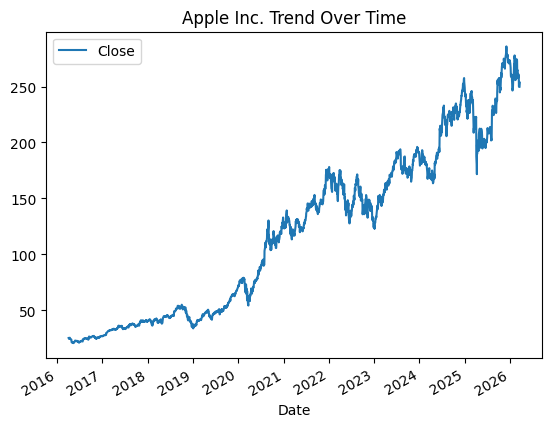

In [35]:
chart= df.plot.line(y="Close", title= (f"{name} Trend Over Time"), use_index=True);


## Setting up Prediction.

Creating a next day column and the closing price.

In [ ]:
df["Next Day"]= df["Close"].shift(-1)

In [37]:
df["Target"] = (df["Next Day"] >df["Close"]).astype(int)

In [38]:
df

,Open,Close,MA_5,MA_10,Lag_1,Next Day,Target
Date,,,,,,,
2016-04-04 06:00:00+02:00,25.007970,25.166508,24.792363,24.391040,24.910585,24.869822,0
2016-04-05 06:00:00+02:00,24.801878,24.869822,24.888844,24.479367,25.166508,25.130274,1
2016-04-06 06:00:00+02:00,24.964944,25.130274,24.952259,24.575395,24.869822,24.582191,0
2016-04-07 06:00:00+02:00,24.901528,24.582191,24.931876,24.629977,25.130274,24.609373,1
2016-04-08 06:00:00+02:00,24.665993,24.609373,24.871634,24.697696,24.582191,24.690893,1
...,...,...,...,...,...,...,...
2026-03-12 06:00:00+02:00,258.660004,255.759995,258.947995,261.019997,260.809998,250.119995,0
2026-03-13 06:00:00+02:00,255.479996,250.119995,257.479996,259.613997,255.759995,252.820007,1
2026-03-16 06:00:00+02:00,252.110001,252.820007,256.067996,258.423997,250.119995,254.229996,1


Target is if the price will go up or down on the next day.

 1 means price will go up,  0 means price will go down.


## Building and training a model

In [39]:
#predictors/ feature matrix
X= ["Open", "Close", "MA_5", "MA_10", "Lag_1"]

#target vector
y= "Target"


#train and test sets
train= df.iloc[:-100]   
test= df.iloc[-100:]

#instatiate model
model= RandomForestClassifier(random_state=1)

#train the model
model.fit(train[X], train[y])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluating the model

In [40]:
preds= model.predict(test[X]) #  numpy array output of predictions.

In [41]:
preds= pd.DataFrame(preds, index= test.index) # array to dataframe

In [42]:
preds.columns= ["Next Day Prediction"] #name the column

In [43]:
precision_score(test[y], preds)

0.44594594594594594

The precision score shows how accurately the model predicted that the price would go up.

## Results

In [44]:
pred_res= pd.concat([test[y], preds], axis=1)

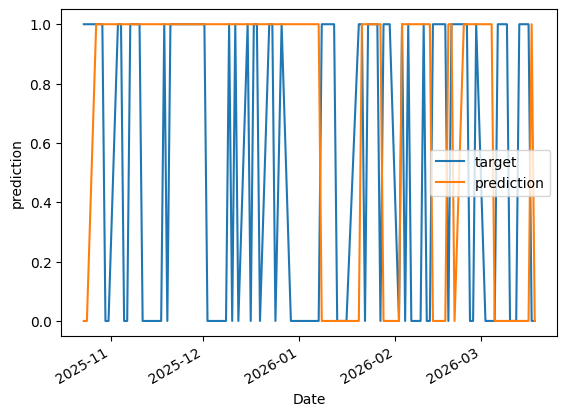

In [45]:
pred_res.plot(ylabel="prediction")
plt.legend(["target", "prediction"]);

Visual summary of model perfomance

In [46]:
preds.tail()

,Next Day Prediction
Date,
2026-03-12 06:00:00+02:00,0
2026-03-13 06:00:00+02:00,0
2026-03-16 06:00:00+02:00,0
2026-03-17 06:00:00+02:00,1
2026-03-18 06:00:00+02:00,0


The Prediction is of the next trading day.

1 means the price is predicted to go up.
0 means the price is predicted to go down.